# Imports

In [ ]:
# !pip install kagglehub
# !pip install opencv-python
# !pip install matplotlib
# !pip install pandas
# !pip install scikit-learn
# !pip install tensorflow

In [2]:
import kagglehub
import os
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import json
import pandas as pd
import random
import keras
from keras import layers
from keras import ops
from keras.layers import Conv2D, AvgPool2D, MaxPool2D, Dropout, Input, Flatten, Dense
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from keras.callbacks import EarlyStopping

# Load in data

In [3]:
path = Path(kagglehub.dataset_download("barrettotte/resistors"))

100%|██████████| 239M/239M [00:01<00:00, 136MB/s]

Extracting files...


In [4]:
os.listdir(path)

['4-band', 'train.csv', 'README.md', '5-band']

## Load in CSV

In [5]:
df = pd.read_csv(path / "train.csv")
df

,image,band_count,ohms,tolerance,watts,bands
0,4-band\4B-100K-T5\4B-100K-T5-1.jpg,4,100000.0,0.05,0.25,brown black yellow gold
1,4-band\4B-100K-T5\4B-100K-T5-10.jpg,4,100000.0,0.05,0.25,brown black yellow gold
2,4-band\4B-100K-T5\4B-100K-T5-2.jpg,4,100000.0,0.05,0.25,brown black yellow gold
3,4-band\4B-100K-T5\4B-100K-T5-3.jpg,4,100000.0,0.05,0.25,brown black yellow gold
4,4-band\4B-100K-T5\4B-100K-T5-4.jpg,4,100000.0,0.05,0.25,brown black yellow gold
...,...,...,...,...,...,...
1265,5-band\5B-9K1-T1\5B-9K1-T1-5.jpg,5,9100.0,0.01,0.25,white brown black brown brown
1266,5-band\5B-9K1-T1\5B-9K1-T1-6.jpg,5,9100.0,0.01,0.25,white brown black brown brown
1267,5-band\5B-9K1-T1\5B-9K1-T1-7.jpg,5,9100.0,0.01,0.25,white brown black brown brown
1268,5-band\5B-9K1-T1\5B-9K1-T1-8.jpg,5,9100.0,0.01,0.25,white brown black brown brown


## Load in 4 band data

In [6]:
with open(path / "4-band" / "4-band.json", "r") as file:
    four_band_json = json.load(file)

In [7]:
four_band_images = []

for folder in os.listdir(path / "4-band"):
    if ".json" in folder:
      continue
    for image in os.listdir(path / "4-band" / folder):
        current_image = cv2.imread((path / "4-band" / folder / image), cv2.IMREAD_COLOR_RGB)
        index = df[df["image"].str.contains(fr"4-band\{folder}\{image}", regex=False)].index[0]
        four_band_images.append((index, current_image))

JSON

In [8]:
print(json.dumps(four_band_json, indent=4))

{
    "1": [
        "black",
        "brown",
        "black",
        "gold"
    ],
    "1.2": [
        "brown",
        "red",
        "gold",
        "gold"
    ],
    "1.5": [
        "brown",
        "green",
        "gold",
        "gold"
    ],
    "1.8": [
        "brown",
        "grey",
        "gold",
        "gold"
    ],
    "2.2": [
        "red",
        "red",
        "gold",
        "gold"
    ],
    "2.7": [
        "red",
        "violet",
        "gold",
        "gold"
    ],
    "3.3": [
        "orange",
        "orange",
        "gold",
        "gold"
    ],
    "3.9": [
        "orange",
        "white",
        "gold",
        "gold"
    ],
    "4.3": [
        "yellow",
        "orange",
        "gold",
        "gold"
    ],
    "4.7": [
        "yellow",
        "violet",
        "gold",
        "gold"
    ],
    "5.1": [
        "green",
        "brown",
        "gold",
        "gold"
    ],
    "5.6": [
        "green",
        "blue",
        "gold",
   

Example image

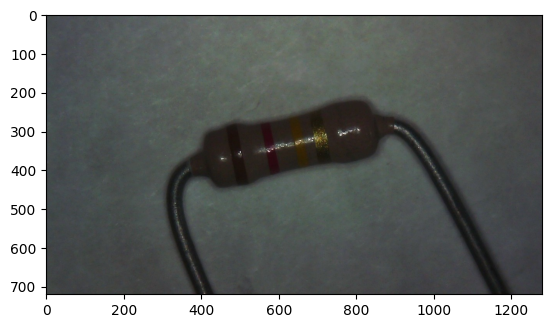

In [9]:
plt.imshow(four_band_images[10][1])

## Load in 5 band data

In [10]:
with open(path / "5-band" / "5-band.json", "r") as file:
    five_band_json = json.load(file)

In [11]:
five_band_images = []

for folder in os.listdir(path / "5-band"):
    if ".json" in folder:
        continue
    for image in os.listdir(path / "5-band" / folder):
        current_image = cv2.imread((path / "5-band" / folder / image), cv2.IMREAD_COLOR_RGB)
        index = df[df["image"].str.contains(fr"5-band\{folder}\{image}", regex=False)].index[0]
        five_band_images.append((index, current_image))

JSON

In [12]:
print(json.dumps(five_band_json, indent=4))

{
    "1": [
        "brown",
        "black",
        "black",
        "silver",
        "brown"
    ],
    "1.5": [
        "brown",
        "green",
        "black",
        "silver",
        "brown"
    ],
    "2.2": [
        "red",
        "red",
        "black",
        "silver",
        "brown"
    ],
    "3.3": [
        "orange",
        "orange",
        "black",
        "silver",
        "brown"
    ],
    "4.7": [
        "yellow",
        "violet",
        "black",
        "silver",
        "brown"
    ],
    "5.1": [
        "green",
        "brown",
        "black",
        "silver",
        "brown"
    ],
    "10": [
        "brown",
        "black",
        "black",
        "gold",
        "brown"
    ],
    "20": [
        "red",
        "black",
        "black",
        "gold",
        "brown"
    ],
    "22": [
        "red",
        "red",
        "black",
        "gold",
        "brown"
    ],
    "33": [
        "orange",
        "orange",
        "black",
     

Example image

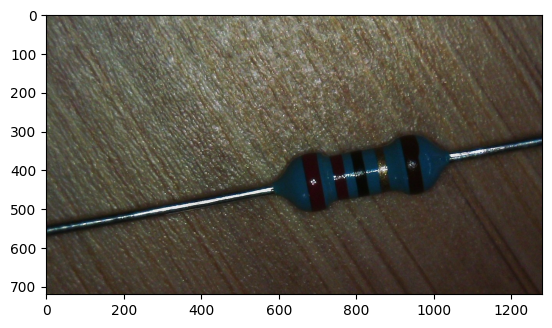

In [13]:
plt.imshow(five_band_images[10][1])

# Data split

In [14]:
merged_image_list = four_band_images + five_band_images
random.shuffle(merged_image_list)

In [15]:
indices_list, image_list = map(list, zip(*merged_image_list))

In [16]:
for i, image in enumerate(image_list):
    resized_image = cv2.resize(image, (224, 224), interpolation=cv2.INTER_LINEAR)
    scaled_image = resized_image.astype(np.float32) / 255.0
    image_list[i] = scaled_image

## Train Test Split

In [17]:
size = len(image_list)
train_size = int(0.8 * size)

train_images = image_list[:train_size]
train_indices = indices_list[:train_size]
train_labels = df.loc[train_indices, "ohms"].values

test_images = image_list[train_size:]
test_indices = indices_list[train_size:]
test_labels = df.loc[test_indices, "ohms"].values

## MinMax Scaling

In [29]:
train_labels_log = np.log10(train_labels)
test_labels_log = np.log10(test_labels)

train_labels_log = train_labels_log.reshape(-1, 1)
test_labels_log = test_labels_log.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))

train_labels_scaled = scaler.fit_transform(train_labels_log)
test_labels_scaled = scaler.transform(test_labels_log)

In [30]:
train_images = np.array(train_images)
test_images = np.array(test_images)

# Models

In [31]:
def create_base_model():
    base_model = keras.Sequential([
        Input((224, 224, 3)),

        Conv2D(32, (3, 3), activation="relu"),
        AvgPool2D((2, 2), 1),
        Dropout(0.15),

        Conv2D(64, (5, 5), activation="relu"),
        AvgPool2D((2, 2), 1),
        Dropout(0.15),

        Conv2D(64, (3, 3), activation="relu"),
        AvgPool2D((2, 2), 1),
        Dropout(0.15),

        Flatten(),
        Dense(1)
    ])

    base_model.compile(optimizer="Adam", loss="mse", metrics=["mae"])

    return base_model

In [32]:
model_dict = {"Base_Model": create_base_model}

## Cross Validation

In [33]:
def k_fold_cross_validation(model_name, X_train, y_train, K=5, batch_size=32, epochs=20, use_early_stopping=True, patience=5, verbose=1):
    subset_size = len(X_train) // K

    models_histories = []

    best_val_loss = float('inf')
    best_model = None

    # Train model K times, using each subset as a "testing" set over iterations
    for i in range(K):
        start = subset_size * i
        end = subset_size * (i + 1)

        X_val = X_train[start:end]
        y_val = y_train[start:end]

        current_X_train = np.concatenate([X_train[:start], X_train[end:]])
        current_y_train = np.concatenate([y_train[:start], y_train[end:]])

        model = model_dict[model_name]()

        if use_early_stopping:
            early_stop = EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)

        # Get history
        history = model.fit(current_X_train, current_y_train, validation_data=(X_val, y_val), batch_size=batch_size, epochs=epochs, callbacks=[early_stop] if use_early_stopping else [], verbose=verbose)
        models_histories.append(history)

        # Get best model
        final_val_loss = history.history["val_loss"][-1]
        if final_val_loss < best_val_loss:
            best_val_loss = final_val_loss
            best_model = model

    return models_histories, best_model

# Training

In [34]:
models_histories, best_base_model = k_fold_cross_validation("Base_Model", train_images, train_labels_scaled)

Epoch 1/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 16s 438ms/step - loss: 155.8248 - mae: 4.3528 - val_loss: 0.9460 - val_mae: 0.8666
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 253ms/step - loss: 0.1499 - mae: 0.3096 - val_loss: 0.1127 - val_mae: 0.2660
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 253ms/step - loss: 0.0794 - mae: 0.2339 - val_loss: 0.0933 - val_mae: 0.2496
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 240ms/step - loss: 0.0744 - mae: 0.2289 - val_loss: 0.0905 - val_mae: 0.2451
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 233ms/step - loss: 0.0713 - mae: 0.2235 - val_loss: 0.0963 - val_mae: 0.2515
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 229ms/step - loss: 0.0716 - mae: 0.2244 - val_loss: 0.0858 - val_mae: 0.2384
Epoch 7/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 227ms/step - loss: 0.0692 - mae: 0.2206 - val_loss: 0.0858 - val_mae: 0.2383
Epoch 8/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 223ms/step - loss: 0.0679 - mae: 0.2170 - val_loss: 0.0959 - val_mae: 0.2508
Epoch 9/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 225ms/step -

# Evaluation

In [35]:
predictions_scaled = best_base_model.predict(test_images)

predictions_log = scaler.inverse_transform(predictions_scaled)
predictions_ohms = 10**predictions_log

true_labels_log = scaler.inverse_transform(test_labels_scaled)
true_ohms = 10**true_labels_log

for i in range(len(test_images)):
    pred = predictions_ohms[i][0]
    real = true_ohms[i][0]
    error = abs(pred - real)

    if error / real > 0.10:
        print(f"Index {i}: Real: {real:.2f} Ohm, Predicted: {pred:.2f} Ohm, Error: {error/real*100:.2f}%")

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step
Index 0: Real: 27.00 Ohm, Predicted: 1305.99 Ohm, Error: 4737.01%
Index 1: Real: 18.00 Ohm, Predicted: 696.23 Ohm, Error: 3767.92%
Index 2: Real: 1.00 Ohm, Predicted: 9786.14 Ohm, Error: 978514.26%
Index 3: Real: 1.50 Ohm, Predicted: 1480.53 Ohm, Error: 98601.75%
Index 4: Real: 51.00 Ohm, Predicted: 544.47 Ohm, Error: 967.60%
Index 5: Real: 390000.00 Ohm, Predicted: 2693.49 Ohm, Error: 99.31%
Index 6: Real: 22.00 Ohm, Predicted: 1254.45 Ohm, Error: 5602.04%
Index 7: Real: 220000.00 Ohm, Predicted: 118.64 Ohm, Error: 99.95%
Index 8: Real: 2200.00 Ohm, Predicted: 649.36 Ohm, Error: 70.48%
Index 9: Real: 1000000.00 Ohm, Predicted: 7055.03 Ohm, Error: 99.29%
Index 10: Real: 5100.00 Ohm, Predicted: 2026.49 Ohm, Error: 60.26%
Index 11: Real: 680.00 Ohm, Predicted: 918.54 Ohm, Error: 35.08%
Index 12: Real: 100.00 Ohm, Predicted: 669.02 Ohm, Error: 569.02%
Index 13: Real: 180000.00 Ohm, Predicted: 327.01 Ohm, Error: 99.82%
Index 14: Real: 150000.00 Ohm, P

In [41]:
predictions_scaled

array([[0.4670107 ],
       [0.4260654 ],
       [0.5981045 ],
       [0.4751753 ],
       [0.41006258],
       [0.51412845],
       [0.46438965],
       [0.31088337],
       [0.42152935],
       [0.57680494],
       [0.49560806],
       [0.44410273],
       [0.42347047],
       [0.376878  ],
       [0.50668544],
       [0.5139443 ],
       [0.5770799 ],
       [0.38579714],
       [0.50855064],
       [0.3504027 ],
       [0.5134675 ],
       [0.5104592 ],
       [0.40185064],
       [0.31012788],
       [0.40843987],
       [0.46587512],
       [0.4657058 ],
       [0.32292986],
       [0.38577303],
       [0.36807403],
       [0.47527838],
       [0.4839354 ],
       [0.3890444 ],
       [0.40932626],
       [0.25504494],
       [0.47897246],
       [0.4208005 ],
       [0.45879173],
       [0.51103985],
       [0.35539123],
       [0.5011101 ],
       [0.6630046 ],
       [0.436813  ],
       [0.40728012],
       [0.35544422],
       [0.6401383 ],
       [0.38324064],
       [0.535